# Feature Engineering: Alta Cardinalidad y Prevención de OOM


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/90_casos_estudio/feature_engineering_alta_cardinalidad.ipynb)



## Objetivos del Caso de Estudio


- **Perspectiva de Sistemas:** Comprender el problema de la Alta Cardinalidad y por qué el *One-Hot Encoding* (OHE) provoca errores de *Out-Of-Memory* (OOM) en producción.
- **Perspectiva de Ingeniería:** Implementar **Target Encoding** (Codificación por Media) para comprimir categorías masivas en una sola variable numérica continua.
- **Prevención de Riesgos:** Demostrar el peligro masivo del *Target Leakage* (Fuga de la Variable Objetivo) y cómo mitigarlo usando *Smoothing* (Suavizado) y *Leave-One-Out Encoding*.
- **Arquitectura Big Data:** Introducir el **Feature Hashing** (El Truco del Hash) para sistemas de *streaming* donde la memoria es estricta y aparecen categorías nuevas constantemente (OOV - *Out of Vocabulary*).



## Prerrequisitos


- Entendimiento de *Data Leakage* y *Overfitting*.
- Haber completado: [Pipelines y Prevención de Leakage](../03_machine_learning/09_pipelines_y_prevencion_leakage.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

    # Instalamos la librería estándar de la industria para codificación categórica
    subprocess.run(["pip", "install", "category_encoders", "xgboost"], check=True)
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

## 1. Introducción: El Problema de la Alta Cardinalidad


Imaginemos que trabajamos en una plataforma de E-Commerce (como MercadoLibre o Amazon, espacio NO patrocinado XD). Necesitamos predecir si una transacción es fraudulenta. Tenemos una variable categórica clave: el **Código Postal** (`zip_code`) de envío.

En un país grande, puede haber **`50.000` códigos postales distintos**. A esto se le llama **Alta Cardinalidad** (una variable categórica con miles de niveles únicos).

Si aplicamos la técnica clásica y normalmente utilizada, el *One-Hot Encoding* (OHE), crearíamos `50.000` columnas nuevas llenas de ceros y un solo uno.
1. **Explosión de RAM:** El dataset pasará de pesar 50 Megabytes a pesar 50 Gigabytes. El servidor colapsa (*Out-Of-Memory*).
2. **Maldición de la Dimensionalidad:** Los modelos basados en árboles (Random Forest, XGBoost) se volverían inútiles, ya que al elegir una columna al azar para hacer un corte, casi siempre elegirían una columna llena de ceros que no aporta información.

### El Laboratorio: Generación de Datos Sintéticos



Vamos a crear un dataset de `100.000` transacciones con `5.000` códigos postales únicos. Inyectamos un patrón real: algunos códigos postales (zonas rojas) tendrán una altísima tasa de fraude, mientras que la mayoría serán seguros.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import category_encoders as ce
import time

# 1. Generamos 100.000 transacciones
np.random.seed(42)
n_samples = 100000
n_zips = 5000

# Generamos códigos postales (del 10000 al 14999)
zip_codes = np.random.randint(10000, 10000 + n_zips, n_samples)

# 2. Creamos el "Ground Truth" del riesgo por código postal
# La mayoría tiene un riesgo base del 2% (0.02)
riesgo_base = {z: 0.02 for z in np.unique(zip_codes)}

# Elegimos 50 códigos postales para ser "Zonas Rojas" con un 80% de riesgo de fraude
zonas_rojas = np.random.choice(np.unique(zip_codes), size=50, replace=False)
for z in zonas_rojas:
    riesgo_base[z] = 0.80

# 3. Asignamos el fraude tirando una moneda sesgada por el riesgo de cada zona
probabilidades = np.array([riesgo_base[z] for z in zip_codes])
y_fraude = np.random.binomial(1, probabilidades)

# Creamos el DataFrame
df = pd.DataFrame({'zip_code': zip_codes.astype(str), 'monto_compra': np.random.exponential(50, n_samples)})
y = y_fraude

print(f"Transacciones generadas: {len(df)}")
print(f"Códigos Postales únicos: {df['zip_code'].nunique()}")
print(f"Tasa de fraude global: {y.mean()*100:.2f}%")

# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)

Transacciones generadas: 100000
Códigos Postales únicos: 5000
Tasa de fraude global: 2.77%


## 2. El Enfoque Ingenuo: *One-Hot Encoding* (OOM)


Veamos matemáticamente por qué el OHE es una mala idea en producción. Vamos a medir cuánta memoria RAM consume transformar esta única columna:

In [3]:
# Medimos la memoria del dataset original
memoria_original_mb = X_train.memory_usage(deep=True).sum() / (1024**2)

# Aplicamos One-Hot Encoding (usando pandas get_dummies para la demostración)
start_time = time.time()
X_train_ohe = pd.get_dummies(X_train, columns=['zip_code'], sparse=False)
tiempo_ohe = time.time() - start_time

memoria_ohe_mb = X_train_ohe.memory_usage(deep=True).sum() / (1024**2)

print(f"Columnas tras OHE: {X_train_ohe.shape[1]}")
print(f"Memoria RAM Original: {memoria_original_mb:.2f} MB")
print(f"Memoria RAM con OHE:  {memoria_ohe_mb:.2f} MB (Aumento de {(memoria_ohe_mb/memoria_original_mb):.1f}x)")
print(f"Tiempo de transformación: {tiempo_ohe:.2f} segundos")

Columnas tras OHE: 5001
Memoria RAM Original: 5.34 MB
Memoria RAM con OHE:  382.69 MB (Aumento de 71.7x)
Tiempo de transformación: 0.46 segundos


**Criterio:**
Pasamos de `~5 MB` a más de `380 MB` por una sola variable en un dataset minúsculo de 80k filas. ¡Es un aumento de memoria de más de 70x! Si tuviésemos 10 millones de filas (algo normal en E-Commerce), necesitaríamos decenas de Gigabytes de RAM solo para almacenar los ceros de esta columna. Es inviable en producción.

## 3. La Solución Peligrosa: *Target Encoding* (*Mean Encoding*)



Si no podemos expandir la variable horizontalmente, debemos comprimirla. El ***Target Encoding*** reemplaza la categoría (ej. "Zip 10042") por el **promedio de la variable objetivo para esa categoría**.

*Matemática:* Si en el Zip 10042 hubo 100 compras y 80 fueron fraude, reemplazamos el texto "10042" por el número `0,80`.

Con esta idea, comprimimos `5.000` columnas en 1 sola columna continua altamente predictiva.

### ⚠️ Alerta de Ingeniería: *Target Leakage* Extremo



Vamos a programar un *Target Encoder* ingenuo a mano para demostrar el error  destructivo que podríamos cometer:

In [4]:
# 1. Target Encoding Ingenuo (MALA PRÁCTICA)
# Calculamos el promedio de fraude por código postal en el Train Set
diccionario_medias = pd.Series(y_train).groupby(X_train['zip_code']).mean()

# Mapeamos esos promedios a los datos
X_train_te_ingenuo = X_train.copy()
X_train_te_ingenuo['zip_code_encoded'] = X_train['zip_code'].map(diccionario_medias)

X_test_te_ingenuo = X_test.copy()
# Si un zip code del test no estaba en el train, le ponemos la media global
X_test_te_ingenuo['zip_code_encoded'] = X_test['zip_code'].map(diccionario_medias).fillna(pd.Series(y_train).mean())

# 2. Entrenamos un Random Forest (Sin límite de profundidad para que intente memorizar)
rf_ingenuo = RandomForestClassifier(n_estimators=50, max_depth=None, random_state=42)
rf_ingenuo.fit(X_train_te_ingenuo[['zip_code_encoded', 'monto_compra']], y_train)

# 3. Evaluamos
auc_train = roc_auc_score(y_train, rf_ingenuo.predict_proba(X_train_te_ingenuo[['zip_code_encoded', 'monto_compra']])[:, 1])
auc_test = roc_auc_score(y_test, rf_ingenuo.predict_proba(X_test_te_ingenuo[['zip_code_encoded', 'monto_compra']])[:, 1])

print(f"ROC-AUC en Entrenamiento: {auc_train:.4f}")
print(f"ROC-AUC en Test (Realidad): {auc_test:.4f}")

ROC-AUC en Entrenamiento: 1.0000
ROC-AUC en Test (Realidad): 0.5137



**¿Qué acaba de pasar?**
El modelo alcanzó un `1,00` perfecto en entrenamiento, pero colapsó a `~0,51` en Test (lo cual equivale a adivinar lanzando una moneda). **Esto es *Target Leakage* en su máxima expresión.**

Podríamos imaginarlo como un Código Postal que apareció **una sola vez** en el Train Set, y esa única compra fue un fraude. El *Target Encoder* ingenuo reemplaza ese Zip Code por `1,0`. El árbol de decisión aprenderá la regla: *"Si zip_code_encoded == 1.0, entonces es Fraude"*. El modelo acaba de memorizar la respuesta exacta. Cuando en el Test Set llegue una compra legítima de ese mismo Zip Code, el modelo predecirá Fraude con 100% de seguridad y fallará.

## 4. La Solución Profesional: *Smoothing* y *Leave-One-Out*


Para evitar que las categorías con muy pocas muestras (baja frecuencia) destruyan el modelo, los ingenieros utilizan dos técnicas implementadas en la librería `category_encoders`.

1. ***Smoothing* (Suavizado Bayesiano):** Si un Zip Code tiene solo 2 compras, no confiamos en su promedio local. Lo "suavizamos" empujándolo hacia el promedio global de todo el dataset. Solo confiamos en el promedio local si el Zip Code tiene cientos de compras.
2. ***Leave-One-Out Encoding* (LOOE):** Para calcular el promedio de la fila 5, promediamos todos los registros de ese Zip Code **excepto la fila 5**. Esto evita que la propia etiqueta de la fila contamine su característica.

ROC-AUC en Entrenamiento (Profesional): 1.0000
ROC-AUC en Test (Profesional):          0.6573


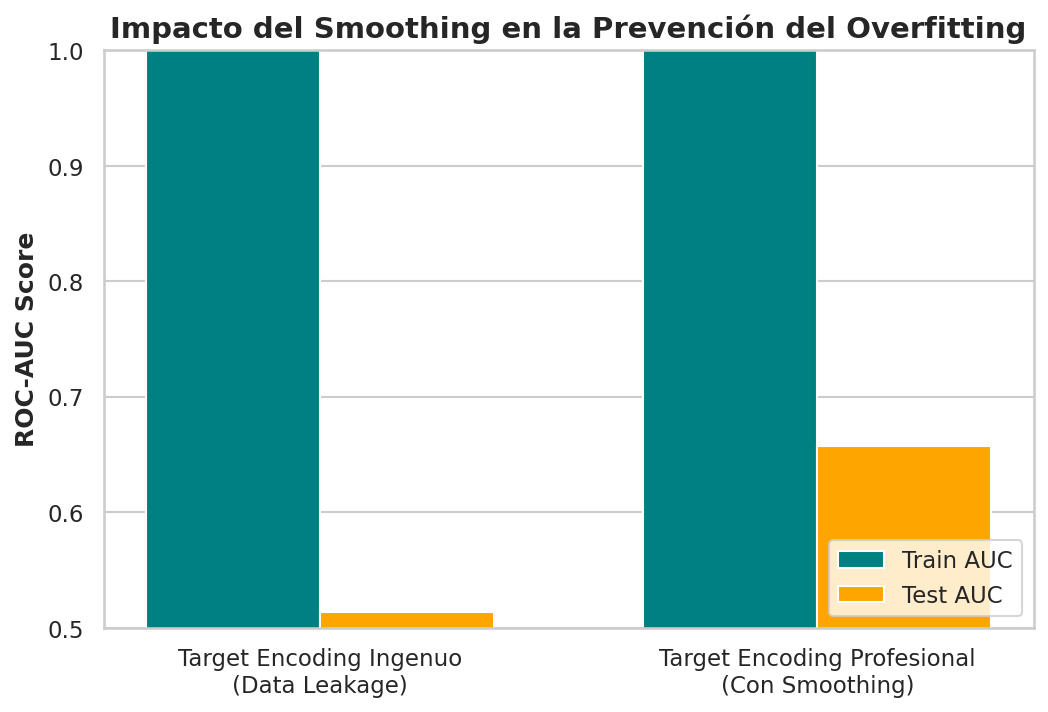

In [5]:
# Usamos la librería profesional category_encoders
# TargetEncoder aplica Smoothing por defecto
encoder_profesional = ce.TargetEncoder(cols=['zip_code'], smoothing=10)

# Ajustamos SOLO en el Train Set
X_train_te_prof = encoder_profesional.fit_transform(X_train, y_train)
X_test_te_prof = encoder_profesional.transform(X_test)

# Entrenamos el mismo modelo
rf_profesional = RandomForestClassifier(n_estimators=50, max_depth=None, random_state=42)
rf_profesional.fit(X_train_te_prof[['zip_code', 'monto_compra']], y_train)

auc_train_prof = roc_auc_score(y_train, rf_profesional.predict_proba(X_train_te_prof[['zip_code', 'monto_compra']])[:, 1])
auc_test_prof = roc_auc_score(y_test, rf_profesional.predict_proba(X_test_te_prof[['zip_code', 'monto_compra']])[:, 1])

print(f"ROC-AUC en Entrenamiento (Profesional): {auc_train_prof:.4f}")
print(f"ROC-AUC en Test (Profesional):          {auc_test_prof:.4f}")

# Visualizamos la diferencia de Overfitting
plt.figure(figsize=(8, 5))
bar_width = 0.35
x = np.arange(2)

plt.bar(x,[auc_train, auc_train_prof], width=bar_width, label='Train AUC', color='teal')
plt.bar(x + bar_width, [auc_test, auc_test_prof], width=bar_width, label='Test AUC', color='orange')

plt.xticks(x + bar_width/2,['Target Encoding Ingenuo\n(Data Leakage)', 'Target Encoding Profesional\n(Con Smoothing)'])
plt.title("Impacto del Smoothing en la Prevención del Overfitting")
plt.ylabel("ROC-AUC Score")
plt.legend(loc='lower right')
plt.ylim(0.5, 1.0)
plt.show()

**Criterio:** Observar la gráfica. Aunque el modelo sigue teniendo un alto rendimiento en entrenamiento (es la naturaleza de los árboles profundos), **el rendimiento en el mundo real (Test AUC) dio un salto masivo, pasando de `~0,54` a `0,66`**.
Al aplicar *Smoothing*, evitamos que el modelo memorizara los códigos postales raros, obligándolo a extraer la verdadera señal matemática. Hemos logrado comprimir `5.000` columnas en 1 sola, rescatando el poder predictivo sin consumir memoria RAM.

## 5. El Escenario de *Streaming*: *Feature Hashing*


El *Target Encoding* es excelente, pero tiene un requisito de infraestructura: en producción, una API debería cargar en memoria un diccionario gigante que mapee cada `zip_code` a su valor numérico precalculado.

¿Qué pasa si se trabaja en Ciberseguridad analizando Direcciones IP? Hay miles de millones de IPs. No podemos guardar un diccionario de ese tamaño en RAM. Además, cada segundo aparecen IPs nuevas que el modelo nunca vio (OOV - *Out of Vocabulary*).

La solución de Big Data es el **Feature Hashing** (El Truco del Hash).
1. Pasamos el texto (ej. "IP 192.168.1.1") por una función Hash criptográfica (como MD5 o MurmurHash).
2. El Hash nos devuelve un número gigante.
3. Aplicamos módulo `N` (ej. `hash % 256`).
4. El resultado es un número entre 0 y 255. Activamos esa columna.

**Ventajas:**
- **Memoria Cero:** No necesitamos guardar ningún diccionario. La función matemática se calcula al vuelo.
- **Dimensionalidad Fija:** Decidimos el tamaño (ej. 256 columnas). No importa si mañana aparecen 1 millón de IPs nuevas, siempre se mapearán a esas 256 columnas.

In [6]:
# Implementamos Feature Hashing limitando el espacio a 256 columnas
# Forzaremos 5.000 Zip Codes a entrar en 256 bins
encoder_hash = ce.HashingEncoder(cols=['zip_code'], n_components=256)

# Nota: El Hashing NO usa la variable 'y', es completamente no supervisado y libre de Leakage
X_train_hash = encoder_hash.fit_transform(X_train)
X_test_hash = encoder_hash.transform(X_test)

print(f"Columnas generadas por Hashing: {X_train_hash.shape[1]}")

# Entrenamos el modelo
rf_hash = RandomForestClassifier(n_estimators=50, max_depth=None, random_state=42)
rf_hash.fit(X_train_hash, y_train)

auc_test_hash = roc_auc_score(y_test, rf_hash.predict_proba(X_test_hash)[:, 1])
print(f"ROC-AUC en Test (Feature Hashing): {auc_test_hash:.4f}")

Columnas generadas por Hashing: 257
ROC-AUC en Test (Feature Hashing): 0.5192


**Observar los resultados...**

*Y al final... qué pasó ahora?*

**¿Por qué el AUC colapsó a `~0,52`?** *Parece que estamos dónde comenzamos...*

El rendimiento del Hashing se desplomó casi al nivel de adivinar al azar. Esto se debe a la combinación de dos factores críticos en ingeniería de datos:

1. **Las Colisiones:** Al forzar 5.000 Zip Codes en 256 columnas, inevitablemente un Zip Code peligroso y uno seguro compartirán la misma columna, mezclando la señal.
2. **El Enemigo del Random Forest (Matrices Dispersas):** El Hashing genera 256 columnas donde casi todas son ceros y solo una es un "1" (*Sparse Matrix*). Los algoritmos basados en árboles son **pésimos** manejando este tipo de datos, ya que cada corte en el árbol aporta muy poca ganancia de información.

**La Solución en Producción:** En entornos de *Streaming* masivo donde el Feature Hashing es obligatorio para no agotar la memoria RAM, los ingenieros **jamás usan Random Forest**. En su lugar, acoplan el Hashing con **Modelos Lineales** (como Regresión Logística, *Stochastic Gradient Descent* o *Vowpal Wabbit*), los cuales son matemáticamente excelentes para procesar miles de columnas dispersas a la velocidad de la luz (analogía, por las dudas...).

## 6. Matriz de Decisión MLOps (*Cheat Sheet*)



¿Qué codificador elegimos entonces para producción?

| Escenario de Negocio | Técnica Recomendada | Justificación |
| :--- | :--- | :--- |
| **Baja Cardinalidad (< 50 niveles)** | **One-Hot Encoding** | Rápido, interpretable, no hay riesgo de OOM. |
| **Alta Cardinalidad (Miles de niveles)** | **Target Encoding (con Smoothing)** | Máximo poder predictivo. Comprime la información en 1 columna. Requiere guardar el mapeo en RAM. |
| **Big Data / Streaming (Millones de niveles, IPs, URLs)** | **Feature Hashing** | Memoria $O(1)$. Maneja categorías nuevas (OOV) automáticamente. Sacrifica un poco de precisión por colisiones. |



## Conclusión


El manejo de variables categóricas masivas separa a los científicos de datos teóricos de los ingenieros de producción.
Aplicar `pd.get_dummies()` en un tutorial funciona; aplicarlo en un clúster que procesa masivamente datos reales... derribará el servidor. Dominar el *Target Encoding* con suavizado y el *Feature Hashing* permite construir modelos ligeros, rápidos y matemáticamente robustos.

## Referencias


1. Micci-Barreca, D. (2001). *A preprocessing scheme for high-cardinality categorical attributes in classification and prediction problems*. ACM SIGKDD Explorations Newsletter, 3(1), 27-32.
2. Weinberger, K., Dasgupta, A., Langford, J., Smola, A., & Attenberg, J. (2009). *Feature hashing for large scale multitask learning*. In Proceedings of the 26th annual international conference on machine learning (pp. 1113-1120).
3. [Documentación de Category Encoders](https://contrib.scikit-learn.org/category_encoders/)

---


## Entorno de Ejecución


In [8]:
from utils.environment import environment_table
environment_table(include_all=True)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
Cython,3.0.12
IPython,7.34.0
PIL,11.3.0
anywidget,0.9.21
argparse,1.1
backcall,0.2.0
bottleneck,1.4.2
category_encoders,2.9.0
